# **Lab 04.2 - Policy-Based Reinforcement Learning for Edge Offloading**


##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This lab consists of 7 practical sections:
<ol style="margin-left: 20px;">
  <li><strong>Part 1: Build EdgeOffloadingEnv and Validate Environment Behavior</strong> (2-layer system: device and edge, check_env and short rollout))</li>
  <li><strong>Part 2: Baseline Policies</strong> (random, device-only, edge-only, greedy)</li>
  <li><strong>Part 3: REINFORCE</strong> (from scratch)</li>
  <li><strong>Part 4: Actor-Critic</strong> (from scratch)</li>
  <li><strong>Part 5: A2C</strong> (from scratch)</li>
  <li><strong>Part 6: Final Comparison + Reflection</strong></li>
</ol>
</div>

In [1]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
# os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
# os.environ['OMP_NUM_THREADS'] = '1'
# os.environ['MKL_NUM_THREADS'] = '1'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Limit PyTorch threading for kernel stability on macOS
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Reproducibility
SEED = 42
FAST_MODE = True
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device info
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

# Shared plotting helpers
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def moving_average(values, window=20):
    """Smooth a learning curve using a moving average."""
    if len(values) == 0:
        return np.array([])
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()


def plot_curve(values, title, ylabel, window=20):
    """Plot raw values together with a moving average."""
    x = np.arange(1, len(values) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, alpha=0.35, label='Episode value')
    plt.plot(x, moving_average(values, window), lw=2, label=f'{window}-episode moving average')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_edge_policy(env_fn, action_fn, episodes=100):
    """Evaluate a policy on EdgeOffloadingEnv and return summary metrics."""
    episode_rewards, episode_avg_latencies, all_latencies = [], [], []
    action_counts = np.zeros(2, dtype=np.int64)

    for ep in range(episodes):
        env = env_fn(SEED + 2000 + ep)
        state, _ = env.reset(seed=SEED + 2000 + ep)

        done = False
        rewards, latencies = [], []

        while not done:
            action = int(action_fn(state, env))
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            latencies.append(info['latency'])
            action_counts[action] += 1
            done = terminated or truncated

        env.close()
        episode_rewards.append(float(np.sum(rewards)))
        episode_avg_latencies.append(float(np.mean(latencies)))
        all_latencies.extend(latencies)

    all_latencies = np.array(all_latencies, dtype=np.float32)
    total_actions = int(action_counts.sum())

    return {
        'episode_rewards': np.array(episode_rewards, dtype=np.float32),
        'episode_avg_latencies': np.array(episode_avg_latencies, dtype=np.float32),
        'all_latencies': all_latencies,
        'action_counts': action_counts,
        'avg_latency': float(np.mean(all_latencies)),
        'p95_latency': float(np.percentile(all_latencies, 95)),
        'avg_reward': float(np.mean(episode_rewards)),
        'device_pct': float(action_counts[0] / total_actions * 100.0),
        'edge_pct': float(action_counts[1] / total_actions * 100.0),
    }

Device: cuda
PyTorch: 2.5.1+cu121
NumPy: 2.2.6
Gymnasium: 1.2.3
FAST_MODE: True


In [2]:
print("\n" + "="*60)
print("PART 1: EDGE OFFLOADING ENVIRONMENT")
print("="*60)

class EdgeOffloadingEnv(gym.Env):
    """Custom edge offloading environment for RL training.
    
    State: [input_size, workload, uplink_rate, edge_queue]
    Actions: 0 = device execution, 1 = edge offloading
    Reward: -latency (minimizing latency)
    """

    metadata = {'render_modes': ['human']}

    OBS_LOW = np.array([1.0, 0.1, 2.0, 0.0], dtype=np.float32)
    OBS_HIGH = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)

    def __init__(self, max_steps=50):
        """Initialize environment parameters.
        
        Args:
            max_steps: Maximum steps per episode
        """
        super().__init__()
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.f_device = 1.0  # GHz
        self.f_edge = 5.0    # GHz
        self.max_steps = int(max_steps)
        self.step_count = 0
        self.state = None

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(
            low=self.OBS_LOW,
            high=self.OBS_HIGH,
            shape=(4,),
            dtype=np.float32,
        )

    def _sample_state(self):
        """Sample a new random state.
        
        Returns:
            State array: [input_size, workload, uplink_rate, edge_queue]
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        return self.np_random.uniform(low=self.OBS_LOW,high=self.OBS_HIGH).astype(np.float32)

    def _compute_latencies(self, state):
        """Compute execution latencies for device and edge.
        
        Args:
            state: Current state [input_size, workload, uplink_rate, edge_queue]
            
        Returns:
            Tuple (latency_device, latency_edge) in milliseconds
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###

        input_size, workload, uplink_rate, edge_queue = np.asarray(state, dtype=np.float32)

        latency_device = (workload / self.f_device) * 1000.0
        upload_latency = (input_size / uplink_rate) * 1000.0
        latency_edge = upload_latency + edge_queue + (workload / self.f_edge) * 1000.0

        return float(latency_device), float(latency_edge)

    def reset(self, seed=None, options=None):
        """Reset environment to initial state.
        
        Args:
            seed: Random seed for reproducibility
            options: Additional reset options
            
        Returns:
            Tuple (observation, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        super().reset(seed=seed)
        self.step_count = 0
        self.state = self._sample_state()
        return self.state.copy(), {}

    def step(self, action):
        """Execute one step in the environment.
        
        Args:
            action: 0 for device execution, 1 for edge offloading
            
        Returns:
            Tuple (observation, reward, terminated, truncated, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###

        if self.state is None:
            raise RuntimeError('Call reset() before step().')
        if not self.action_space.contains(action):
            raise ValueError(f'Invalid action {action}. Expected 0=device or 1=edge.')

        action = int(action)
        latency_device, latency_edge = self._compute_latencies(self.state)
        selected_latency = latency_device if action == 0 else latency_edge
        reward = -selected_latency / 1000.0

        self.step_count += 1
        terminated = False
        truncated = self.step_count >= self.max_steps

        info = {
            'latency': float(selected_latency),
            'latency_device': float(latency_device),
            'latency_edge': float(latency_edge),
            'action': action,
            'action_name': 'device' if action == 0 else 'edge',
        }

        self.state = self._sample_state()
        return self.state.copy(), float(reward), terminated, truncated, info

    def render(self):
        """Render current environment state."""
        if self.state is None:
            print('Environment has not been reset yet.')
        else:
            print(f'Step {self.step_count:02d} | state = {np.round(self.state, 3)}')


# Test environment initialization
print("\nInitializing EdgeOffloadingEnv...")
edge_env = EdgeOffloadingEnv(max_steps=50)
obs, info = edge_env.reset(seed=SEED)
print(f'Initial observation: {np.round(obs, 3)}')
print(f'Initial info: {info}')



PART 1: EDGE OFFLOADING ENVIRONMENT

Initializing EdgeOffloadingEnv...
Initial observation: [ 15.705   1.373  17.455 139.474]
Initial info: {}


---

# PART 2: Environment Validation

Before training any policy, we validate environment API behavior and inspect transition outputs using a short random rollout.

In [3]:
# Environment validation and simple rollout test
print("\nValidating environment...")
try:
    from gymnasium.utils.env_checker import check_env
    check_env(edge_env, skip_render_check=True)
    print("✓ check_env passed successfully.")
except Exception as exc:
    print(f"check_env not available or skipped. Details: {exc}")

# Run a few steps to verify correctness
print("\nTest rollout (5 steps):")
obs, info = edge_env.reset(seed=SEED)
print(f"Initial obs: {np.round(obs, 3)}")

for step_idx in range(5):
    action = edge_env.action_space.sample()
    obs, reward, terminated, truncated, info = edge_env.step(action)
    print(f"Step {step_idx + 1}: action={action}, "
          f"reward={reward:.6f}, "
          f"latency={info['latency']:.2f}ms, "
          f"action_name={info['action_name']}")
    
    if terminated or truncated:
        obs, info = edge_env.reset(seed=SEED + step_idx + 1)
        print("  → Episode truncated, reset.")



Validating environment...
✓ check_env passed successfully.

Test rollout (5 steps):
Initial obs: [ 15.705   1.373  17.455 139.474]
Step 1: action=1, reward=-1.313787, latency=1313.79ms, action_name=edge
Step 2: action=1, reward=-0.920735, latency=920.73ms, action_name=edge
Step 3: action=0, reward=-1.406119, latency=1406.12ms, action_name=device
Step 4: action=1, reward=-1.868452, latency=1868.45ms, action_name=edge
Step 5: action=0, reward=-0.285070, latency=285.07ms, action_name=device


---

# PART 3: Baseline Policies and Evaluation

Before training RL algorithms, we establish baseline policies to understand expected latency and reward scales.

### 3.1 Policy Implementations

We implement four baseline policies:
- **Random**: choose action uniformly at random
- **Device-only**: always execute on device
- **Edge-only**: always offload to edge
- **Greedy latency**: choose action with lower immediate latency


In [4]:
# ============================================================================
# Baseline policy functions
# ============================================================================
### YOU NEED TO WRITE YOUR CODE BELOW ###
def make_edge_env(seed=None, max_steps=50):
    """Create a fresh EdgeOffloadingEnv with optional deterministic seeding."""
    env = EdgeOffloadingEnv(max_steps=max_steps)
    if seed is not None:
        env.action_space.seed(seed)
        env.observation_space.seed(seed)
    return env


def random_policy(state, env):
    """Uniform random baseline."""
    return env.action_space.sample()


def device_only_policy(state, env=None):
    """Always execute on the device."""
    return 0


def edge_only_policy(state, env=None):
    """Always offload to the edge."""
    return 1


def greedy_latency_policy(state, env):
    """Choose the action with the smaller immediate latency."""
    latency_device, latency_edge = env._compute_latencies(state)
    return int(latency_edge < latency_device)


baseline_policies = {
    'Random': random_policy,
    'Device-only': device_only_policy,
    'Edge-only': edge_only_policy,
    'Greedy latency': greedy_latency_policy,
}

print('Baseline policies:', ', '.join(baseline_policies.keys()))


Baseline policies: Random, Device-only, Edge-only, Greedy latency


Random          | avg latency:  1646.79 ms | p95:  3299.88 ms | avg reward:  -82.340 | device:  49.9% | edge:  50.1%
Device-only     | avg latency:  1533.06 ms | p95:  2847.47 ms | avg reward:  -76.653 | device: 100.0% | edge:   0.0%
Edge-only       | avg latency:  1754.79 ms | p95:  4478.38 ms | avg reward:  -87.739 | device:   0.0% | edge: 100.0%
Greedy latency  | avg latency:  1132.28 ms | p95:  2346.86 ms | avg reward:  -56.614 | device:  49.0% | edge:  51.0%


,Policy,Avg Latency (ms),P95 Latency (ms),Avg Reward,Device %,Edge %
0,Greedy latency,1132.280273,2346.855469,-56.614016,48.98,51.02
1,Device-only,1533.064087,2847.472900,-76.653204,100.00,0.00
2,Random,1646.791260,3299.877930,-82.339562,49.94,50.06
3,Edge-only,1754.787964,4478.384766,-87.739396,0.00,100.00


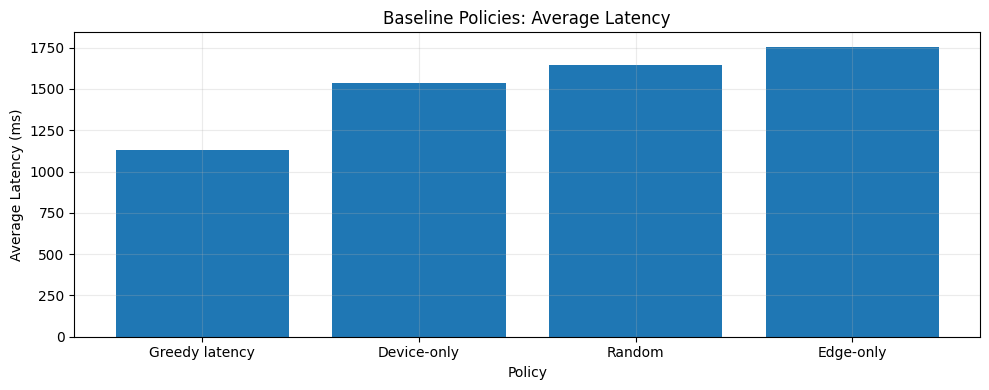

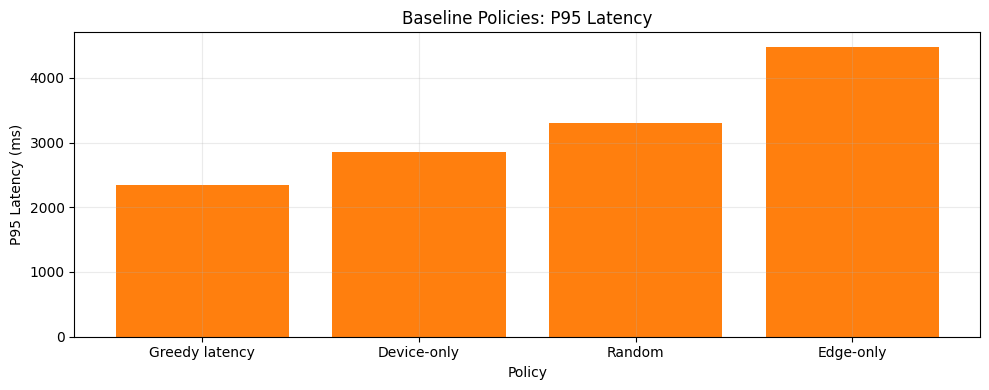

In [5]:
# ============================================================================
# Evaluate baseline policies
# ============================================================================
### YOU NEED TO WRITE YOUR CODE BELOW ###
baseline_eval_episodes = 100 if FAST_MODE else 300
baseline_results = {}

for policy_name, policy_fn in baseline_policies.items():
    result = evaluate_edge_policy(make_edge_env, policy_fn, episodes=baseline_eval_episodes)
    baseline_results[policy_name] = result
    print(f"{policy_name:15s} | "
          f"avg latency: {result['avg_latency']:8.2f} ms | "
          f"p95: {result['p95_latency']:8.2f} ms | "
          f"avg reward: {result['avg_reward']:8.3f} | "
          f"device: {result['device_pct']:5.1f}% | edge: {result['edge_pct']:5.1f}%")

baseline_df = pd.DataFrame([
    {
        'Policy': name,
        'Avg Latency (ms)': result['avg_latency'],
        'P95 Latency (ms)': result['p95_latency'],
        'Avg Reward': result['avg_reward'],
        'Device %': result['device_pct'],
        'Edge %': result['edge_pct'],
    }
    for name, result in baseline_results.items()
]).sort_values('Avg Latency (ms)').reset_index(drop=True)

display(baseline_df)

plt.figure(figsize=(10, 4))
plt.bar(baseline_df['Policy'], baseline_df['Avg Latency (ms)'])
plt.title('Baseline Policies: Average Latency')
plt.xlabel('Policy')
plt.ylabel('Average Latency (ms)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(baseline_df['Policy'], baseline_df['P95 Latency (ms)'], color='tab:orange')
plt.title('Baseline Policies: P95 Latency')
plt.xlabel('Policy')
plt.ylabel('P95 Latency (ms)')
plt.tight_layout()
plt.show()


---

# PART 4: Actor-Critic on EdgeOffloadingEnv

Actor-Critic combines a policy (actor) and a value estimator (critic) for more stable learning than REINFORCE.

### 5.1 Actor and Critic Networks

- **Actor**: outputs action probabilities
- **Critic**: estimates the state value for temporal-difference learning


In [6]:
print("\n" + "="*60)
print("PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV")
print("="*60)

# ============================================================================
# Actor and Critic networks
# ============================================================================
### YOU NEED TO WRITE YOUR CODE BELOW ###
STATE_LOW_TENSOR = torch.tensor(EdgeOffloadingEnv.OBS_LOW, dtype=torch.float32, device=device)
STATE_RANGE_TENSOR = torch.tensor(
    EdgeOffloadingEnv.OBS_HIGH - EdgeOffloadingEnv.OBS_LOW,
    dtype=torch.float32,
    device=device,
)

def state_to_tensor(state):
    """Convert a raw environment state to a normalized torch tensor."""
    state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device)
    return torch.clamp((state_tensor - STATE_LOW_TENSOR) / STATE_RANGE_TENSOR, 0.0, 1.0)

class ActorNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Softmax(dim=-1),
        )

    def forward(self, x):
        return self.net(x)


class CriticNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)



PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV


Actor-Critic episode 50/250 | return: -58.916 | avg latency: 1178.33 ms
Actor-Critic episode 100/250 | return: -56.625 | avg latency: 1132.50 ms
Actor-Critic episode 150/250 | return: -55.111 | avg latency: 1102.22 ms
Actor-Critic episode 200/250 | return: -61.201 | avg latency: 1224.03 ms
Actor-Critic episode 250/250 | return: -62.187 | avg latency: 1243.73 ms


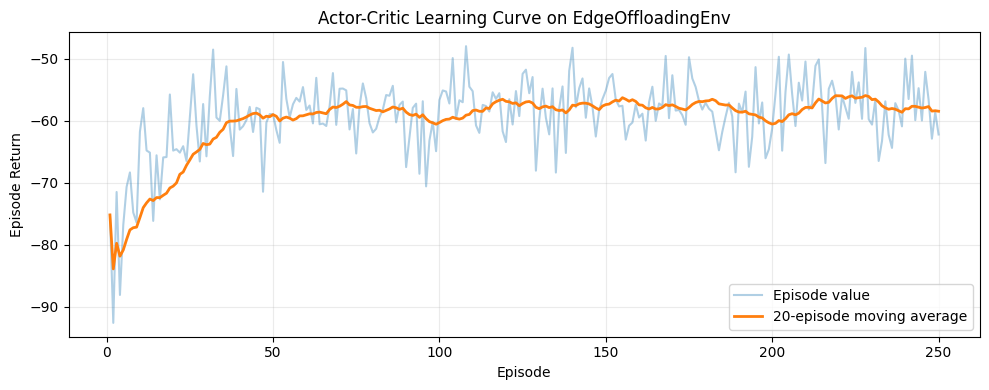

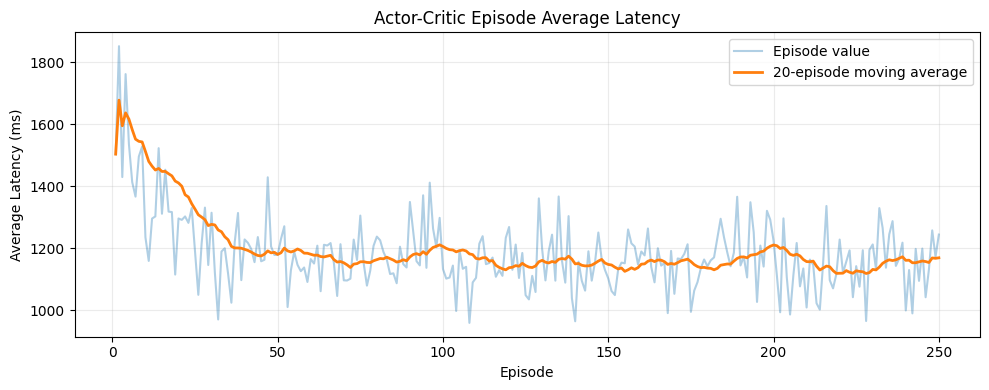

Actor-Critic avg latency: 1142.01 ms
Actor-Critic p95 latency: 2389.04 ms
Actor-Critic avg reward: -57.101
Actor-Critic actions: device=56.3%, edge=43.7%


In [7]:
# ============================================================================
# Actor-Critic training analysis
# ============================================================================
### YOU NEED TO WRITE YOUR CODE BELOW ###

def train_actor_critic_edge(episodes, gamma=0.0, actor_lr=3e-4, critic_lr=1e-3, entropy_coef=0.01):
    """Train an online Actor-Critic agent on EdgeOffloadingEnv."""
    actor = ActorNetwork(input_dim=4, hidden_dim=128, output_dim=2).to(device)
    critic = CriticNetwork(input_dim=4, hidden_dim=128, output_dim=1).to(device)

    actor_optimizer = optim.Adam(actor.parameters(), lr=actor_lr)
    critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)

    episode_rewards = []
    episode_avg_latencies = []

    for ep in range(episodes):
        env = make_edge_env(seed=SEED + 3000 + ep)
        state, _ = env.reset(seed=SEED + 3000 + ep)

        total_reward = 0.0
        latencies = []
        done = False

        while not done:
            state_tensor = state_to_tensor(state).unsqueeze(0)
            probs = actor(state_tensor).squeeze(0)
            dist = Categorical(probs)
            action_tensor = dist.sample()
            log_prob = dist.log_prob(action_tensor)

            value = critic(state_tensor).squeeze()
            next_state, reward, terminated, truncated, info = env.step(int(action_tensor.item()))
            done = terminated or truncated

            next_state_tensor = state_to_tensor(next_state).unsqueeze(0)
            with torch.no_grad():
                next_value = critic(next_state_tensor).squeeze()

            reward_tensor = torch.tensor(reward, dtype=torch.float32, device=device)
            done_mask = 0.0 if done else 1.0
            td_target = reward_tensor + gamma * next_value * done_mask
            advantage = td_target - value

            actor_loss = -(log_prob * advantage.detach()) - entropy_coef * dist.entropy()
            critic_loss = nn.functional.mse_loss(value, td_target.detach())

            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()

            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()

            state = next_state
            total_reward += reward
            latencies.append(info['latency'])

        episode_rewards.append(float(total_reward))
        episode_avg_latencies.append(float(np.mean(latencies)))
        env.close()

        if (ep + 1) % 50 == 0 or (ep + 1) == episodes:
            print(f"Actor-Critic episode {ep + 1}/{episodes} | "
                  f"return: {total_reward:.3f} | "
                  f"avg latency: {np.mean(latencies):.2f} ms")

    return actor, critic, np.array(episode_rewards, dtype=np.float32), np.array(episode_avg_latencies, dtype=np.float32)


actor_critic_episodes = 250 if FAST_MODE else 800
actor_model, critic_model, actor_critic_train_rewards, actor_critic_train_latencies = train_actor_critic_edge(
    episodes=actor_critic_episodes
)

plot_curve(
    actor_critic_train_rewards,
    title='Actor-Critic Learning Curve on EdgeOffloadingEnv',
    ylabel='Episode Return',
    window=20,
)

plot_curve(
    actor_critic_train_latencies,
    title='Actor-Critic Episode Average Latency',
    ylabel='Average Latency (ms)',
    window=20,
)


def actor_critic_action_fn(state, env=None):
    """Deterministic Actor-Critic policy for evaluation."""
    actor_model.eval()
    with torch.no_grad():
        state_tensor = state_to_tensor(state).unsqueeze(0)
        probs = actor_model(state_tensor).squeeze(0)
        return int(torch.argmax(probs).item())


rl_eval_episodes = 100 if FAST_MODE else 300
actor_critic_result = evaluate_edge_policy(make_edge_env, actor_critic_action_fn, episodes=rl_eval_episodes)
print(f"Actor-Critic avg latency: {actor_critic_result['avg_latency']:.2f} ms")
print(f"Actor-Critic p95 latency: {actor_critic_result['p95_latency']:.2f} ms")
print(f"Actor-Critic avg reward: {actor_critic_result['avg_reward']:.3f}")
print(f"Actor-Critic actions: device={actor_critic_result['device_pct']:.1f}%, "
      f"edge={actor_critic_result['edge_pct']:.1f}%")


---

# PART 5: A2C from Scratch 


### 6.1 Custom A2C Training and Evaluation



PART 5: CUSTOM A2C FROM SCRATCH
Custom A2C ep 50 | t=2500/10000 | return=-65.386 | avg latency=1307.72 ms
Custom A2C ep 100 | t=5000/10000 | return=-65.296 | avg latency=1305.92 ms
Custom A2C ep 150 | t=7500/10000 | return=-53.139 | avg latency=1062.77 ms
Custom A2C ep 200 | t=10000/10000 | return=-59.424 | avg latency=1188.48 ms


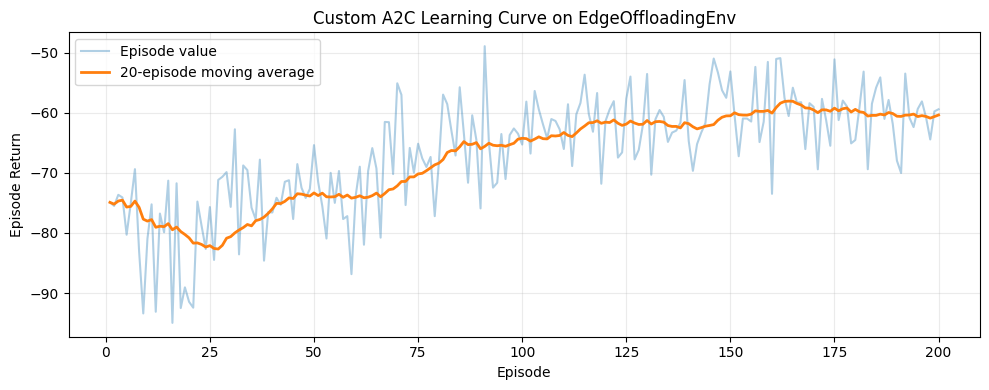

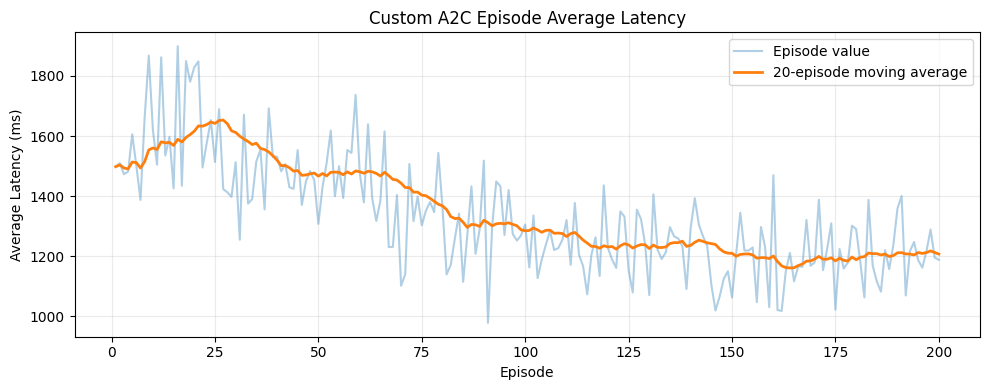

Custom A2C avg latency: 1149.48 ms
Custom A2C p95 latency: 2390.53 ms
Custom A2C avg reward: -57.474
Custom A2C actions: device=48.6%, edge=51.4%


In [8]:
print("\n" + "="*60)
print("PART 5: CUSTOM A2C FROM SCRATCH")
print("="*60)

# ============================================================================
# Custom A2C training and evaluation
# ============================================================================
### YOU NEED TO WRITE YOUR CODE BELOW ###

class A2CNetwork(nn.Module):
    """A2C network with a shared feature extractor and two heads."""

    def __init__(self, input_dim=4, hidden_dim=128, output_dim=2):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.policy_head = nn.Linear(hidden_dim, output_dim)
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        features = self.shared(x)
        logits = self.policy_head(features)
        value = self.value_head(features).squeeze(-1)
        return logits, value


def train_a2c_edge(
    total_timesteps=10000,
    gamma=0.0,
    gae_lambda=0.0,
    lr=5e-4,
    ent_coef=0.005,
    value_coef=0.5,
    n_steps=64,
    max_grad_norm=0.5,
    normalize_advantage=True,
):
    """Train a custom A2C agent on EdgeOffloadingEnv using n-step rollouts and GAE."""
    random.seed(SEED + 5000)
    np.random.seed(SEED + 5000)
    torch.manual_seed(SEED + 5000)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED + 5000)

    model = A2CNetwork(input_dim=4, hidden_dim=128, output_dim=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    episode_rewards = []
    episode_avg_latencies = []
    timestep = 0
    ep_idx = 0

    env = make_edge_env(seed=SEED + 5000)
    state, _ = env.reset(seed=SEED + 5000)

    current_ep_reward = 0.0
    current_ep_latencies = []

    while timestep < total_timesteps:
        rollout_rewards = []
        rollout_dones = []
        rollout_values = []
        rollout_log_probs = []
        rollout_entropies = []

        last_done = False

        for _ in range(n_steps):
            if timestep >= total_timesteps:
                break

            state_t = state_to_tensor(state).unsqueeze(0)
            logits, value = model(state_t)
            dist = Categorical(logits=logits)
            action = dist.sample()

            log_prob = dist.log_prob(action).squeeze()
            entropy = dist.entropy().squeeze()
            value = value.squeeze()

            next_state, reward, terminated, truncated, info = env.step(int(action.item()))
            done = terminated or truncated

            rollout_rewards.append(float(reward))
            rollout_dones.append(done)
            rollout_values.append(value)
            rollout_log_probs.append(log_prob)
            rollout_entropies.append(entropy)

            current_ep_reward += reward
            current_ep_latencies.append(info['latency'])
            timestep += 1

            state = next_state
            last_done = done

            if done:
                episode_rewards.append(float(current_ep_reward))
                episode_avg_latencies.append(float(np.mean(current_ep_latencies)))
                current_ep_reward = 0.0
                current_ep_latencies = []
                ep_idx += 1

                if ep_idx % 50 == 0:
                    print(f"Custom A2C ep {ep_idx} | "
                          f"t={timestep}/{total_timesteps} | "
                          f"return={episode_rewards[-1]:.3f} | "
                          f"avg latency={episode_avg_latencies[-1]:.2f} ms")

                state, _ = env.reset(seed=SEED + 5000 + ep_idx)

        if len(rollout_rewards) == 0:
            continue

        with torch.no_grad():
            if last_done:
                next_value = torch.tensor(0.0, device=device)
            else:
                state_t = state_to_tensor(state).unsqueeze(0)
                _, next_value = model(state_t)
                next_value = next_value.squeeze()

        values_t = torch.stack(rollout_values).view(-1)
        log_probs_t = torch.stack(rollout_log_probs).view(-1)
        entropies_t = torch.stack(rollout_entropies).view(-1)
        rewards_t = torch.tensor(rollout_rewards, dtype=torch.float32, device=device).view(-1)
        dones_t = torch.tensor(rollout_dones, dtype=torch.float32, device=device).view(-1)

        assert values_t.shape == log_probs_t.shape
        assert values_t.shape == entropies_t.shape
        assert values_t.shape == rewards_t.shape
        assert values_t.shape == dones_t.shape

        advantages = torch.zeros_like(rewards_t)
        values_next = torch.cat([values_t[1:], next_value.view(1)])
        last_gae_lam = torch.tensor(0.0, device=device)

        for t in reversed(range(len(rollout_rewards))):
            non_terminal = 1.0 - dones_t[t]
            delta = rewards_t[t] + gamma * values_next[t] * non_terminal - values_t[t]
            last_gae_lam = delta + gamma * gae_lambda * non_terminal * last_gae_lam
            advantages[t] = last_gae_lam

        returns_t = advantages + values_t

        if normalize_advantage and len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        policy_loss = -(log_probs_t * advantages.detach()).mean()
        value_loss = nn.functional.smooth_l1_loss(values_t, returns_t.detach())
        entropy_loss = -entropies_t.mean()
        loss = policy_loss + value_coef * value_loss + ent_coef * entropy_loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

    env.close()

    return (
        model,
        np.array(episode_rewards, dtype=np.float32),
        np.array(episode_avg_latencies, dtype=np.float32),
    )


A2C_TOTAL_TIMESTEPS = 10000 if FAST_MODE else 50000
A2C_MODEL, custom_a2c_train_rewards, custom_a2c_train_latencies = train_a2c_edge(
    total_timesteps=A2C_TOTAL_TIMESTEPS,
    n_steps=64,
    lr=5e-4,
    ent_coef=0.005,
    value_coef=0.5,
    normalize_advantage=True,
    max_grad_norm=0.5,
    gamma=0.0,
    gae_lambda=0.0,
)

plot_curve(
    custom_a2c_train_rewards,
    title='Custom A2C Learning Curve on EdgeOffloadingEnv',
    ylabel='Episode Return',
    window=20,
)

plot_curve(
    custom_a2c_train_latencies,
    title='Custom A2C Episode Average Latency',
    ylabel='Average Latency (ms)',
    window=20,
)


def custom_a2c_action_fn(state, env=None):
    """Deterministic Custom A2C policy for evaluation."""
    A2C_MODEL.eval()
    with torch.no_grad():
        state_t = state_to_tensor(state).unsqueeze(0)
        logits, _ = A2C_MODEL(state_t)
        action = torch.argmax(logits, dim=-1)
        return int(action.item())


a2c_eval_episodes = globals().get('rl_eval_episodes', 100 if FAST_MODE else 300)
custom_a2c_result = evaluate_edge_policy(make_edge_env, custom_a2c_action_fn, episodes=a2c_eval_episodes)

print(f"Custom A2C avg latency: {custom_a2c_result['avg_latency']:.2f} ms")
print(f"Custom A2C p95 latency: {custom_a2c_result['p95_latency']:.2f} ms")
print(f"Custom A2C avg reward: {custom_a2c_result['avg_reward']:.3f}")
print(f"Custom A2C actions: device={custom_a2c_result['device_pct']:.1f}%, "
      f"edge={custom_a2c_result['edge_pct']:.1f}%")

# Compatibility variables for the final comparison cell.
a2c_available = True
a2c_model = A2C_MODEL
a2c_result = custom_a2c_result


---

# PART 6: Final Comparison

We compare all methods (baseline policies, Actor-Critic, and A2C) using shared evaluation metrics.

### 7.1 Aggregated Results Table


,Method,Avg Latency ↓,P95 Latency ↓,Avg Reward ↑,Gap to Greedy ↓,Device %,Edge %
0,Greedy latency,1132.280273,2346.855469,-56.614016,0.000000,48.98,51.02
1,Actor-Critic,1142.013062,2389.040771,-57.100656,9.732788,56.32,43.68
2,Custom A2C,1149.477783,2390.532471,-57.473893,17.197510,48.56,51.44
3,Device-only,1533.064087,2847.472900,-76.653204,400.783813,100.00,0.00
4,Random,1646.791260,3299.877930,-82.339562,514.510986,49.94,50.06
5,Edge-only,1754.787964,4478.384766,-87.739396,622.507690,0.00,100.00


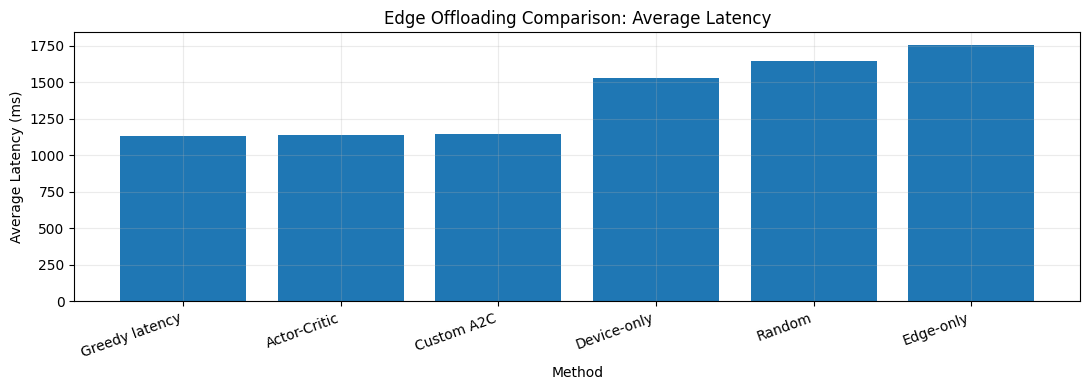

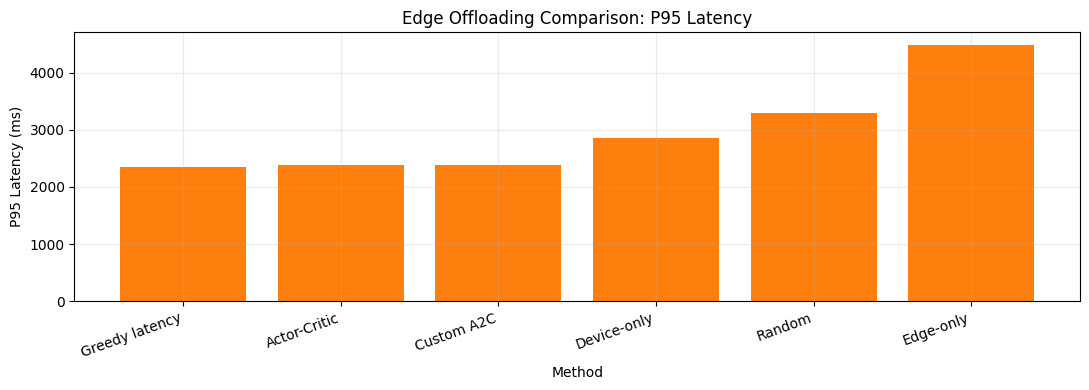

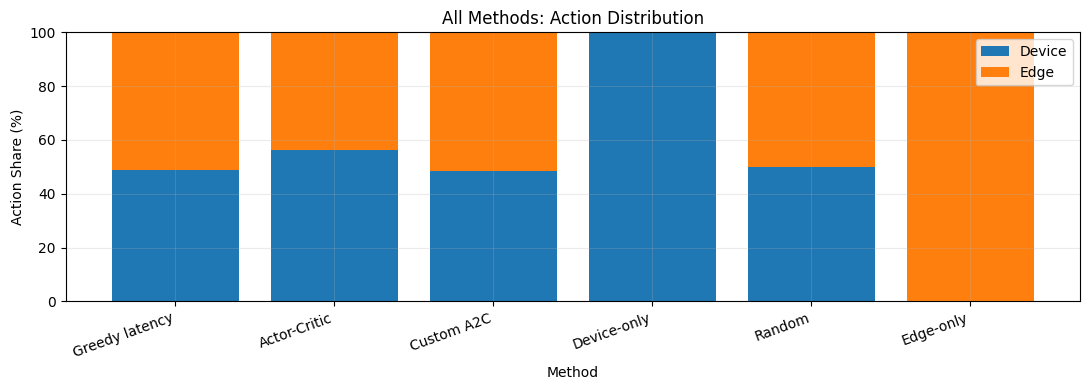

In [9]:
# ============================================================================
# Build comprehensive comparison table
# ============================================================================

comparison_rows = []

def add_result(method_name, result):
    """Add a result row to the comparison table.
    
    Args:
        method_name: Name of the method
        result: Evaluation result dictionary
    """
    comparison_rows.append({
        'Method': method_name,
        'Avg Latency ↓': result['avg_latency'],
        'P95 Latency ↓': result['p95_latency'],
        'Avg Reward ↑': result['avg_reward'],
        'Gap to Greedy ↓': result['avg_latency'] - baseline_results['Greedy latency']['avg_latency'],
        'Device %': result['device_pct'],
        'Edge %': result['edge_pct'],
    })

### YOU NEED TO WRITE YOUR CODE BELOW ###
for method_name, result in baseline_results.items():
    add_result(method_name, result)

add_result('Actor-Critic', actor_critic_result)

if a2c_available and a2c_result is not None:
    add_result('Custom A2C', a2c_result)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('Avg Latency ↓').reset_index(drop=True)

display(comparison_df)

plt.figure(figsize=(11, 4))
plt.bar(comparison_df['Method'], comparison_df['Avg Latency ↓'])
plt.title('Edge Offloading Comparison: Average Latency')
plt.xlabel('Method')
plt.ylabel('Average Latency (ms)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.bar(comparison_df['Method'], comparison_df['P95 Latency ↓'], color='tab:orange')
plt.title('Edge Offloading Comparison: P95 Latency')
plt.xlabel('Method')
plt.ylabel('P95 Latency (ms)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

action_dist_df = comparison_df.copy()
if len(action_dist_df) > 0:
    x = np.arange(len(action_dist_df))
    plt.figure(figsize=(11, 4))
    plt.bar(x, action_dist_df['Device %'], label='Device')
    plt.bar(x, action_dist_df['Edge %'], bottom=action_dist_df['Device %'], label='Edge')
    plt.xticks(x, action_dist_df['Method'], rotation=20, ha='right')
    plt.ylim(0, 100)
    plt.title('All Methods: Action Distribution')
    plt.xlabel('Method')
    plt.ylabel('Action Share (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()


## CONGRATULATIONS TEAM!

Congratulations on Completing Lab 04.2 - Policy-Based Reinforcement Learning for Edge Offloading!

**Key Observations:**

- **REINFORCE** is simple but often has high-variance updates.
- **Actor-Critic** is usually more stable due to TD-based critic guidance.
- **Custom A2C** uses n-step rollouts, GAE, entropy bonus, and a shared actor-critic network.
- On EdgeOffloadingEnv, learned policies can approach strong heuristic behavior.
- The task highlights trade-offs between communication latency and compute placement decisions.

**Why This Matters:**

- Edge systems require fast adaptive offloading decisions.
- Policy-based RL provides a data-driven alternative to hand-crafted decision rules.
- These methods form a foundation for many advanced RL algorithms used in networking systems.

References: https://gymnasium.farama.org/ | https://pytorch.org/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026